# Investigacion respecto a los datos

Hola, este es un notebook donde voy a estar reportando los descubrimientos que voy haciendo respecto a las fases

**Preguntas del caso:** cuales materias primas determinan el precio de cada equipo y cuanto van a costar en los proximos meses

# Fase 1: explorar los datos
Antes de escribir cualquier cosa quiero saber que con que datos estoy tratando, para esto necesito saber como vienen los archivos, si los datos estan bien y que tan de calidad son

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
MATERIAS_PRIMAS=["Price_X","Price_Y","Price_Z"]
EQUIPOS = ["Price_Equipo1", "Price_Equipo2"]
ARCHIVOS=["historico_equipos.csv", "X.csv", "Y.csv", "Z.csv"]
ARCHIVOS_LECTURA = {
    "X": dict(archivo = "X.csv", sep = ",", decimal= ".", dayfirst=False, encoding ="utf-8"),
    "Y": dict(archivo = "Y.csv", sep= ";", decimal = ",", dayfirst= True,encoding ="utf-8-sig"),
    "Z": dict(archivo= "Z.csv", sep=",", decimal= ".", dayfirst=False, encoding ="utf-8")
}

In [2]:
for i in ARCHIVOS:
    with open(f"../Datos/{i}", "rb") as f:
        print(i)
        for _ in range(3):
            print(f.readline())


historico_equipos.csv
b'Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2\n'
b'2010-01-04,80.12,527.5,2225.25,434.73,931.73\n'
b'2010-01-05,80.59,527.5,2246.5,449.97,968.56\n'
X.csv
b'Date,Price\r\n'
b'2024-04-04,89.18\r\n'
b'2024-04-03,89.35\r\n'
Y.csv
b'\xef\xbb\xbfDate;Price\r\n'
b'12/9/2023;547,33\r\n'
b'11/9/2023;546\r\n'
Z.csv
b'Price,Date\r\n'
b'2225.25,2010-01-01\r\n'
b'2225.25,2010-01-04\r\n'


**El '\xef\xbb\xbf al inicio de Y.csv** se le llama BOM, una marca invisible que ponen los programas al guardar,si no lo manejo, la primera se llamara '\ufeffDate' en vez de 'Date', aparte de Y.csv usa punto y como separador y coma como decimal.

Z.csv puedo observar que tiene las col invertidas, Price antes que Date, Por eso el parser riene que seleccionar por nombre y no por posicion.

Otras de las cosas a destacar que es las fechas dentro del archivo Y.csv son ambiguas, 12/9/2023 puede ser 12 de septiempre o 9 de diciembre, lo cual puede confundir, y si, lo interpreto mal toda quedaria desordenado, esto se puede observar mejor con 

In [3]:
with open("../Datos/Y.csv", "rb") as f:
    for _ in range(6):
        print(f.readline())

b'\xef\xbb\xbfDate;Price\r\n'
b'12/9/2023;547,33\r\n'
b'11/9/2023;546\r\n'
b'8/9/2023;545\r\n'
b'7/9/2023;550\r\n'
b'6/9/2023;552,5\r\n'


Leidas como dia/mes son el 12, 11, 8 y 7 de septiembre,  dias consecutivos con el hueco del fin de semana, que es lo normal en una serie de precios de mercado.

Leidas como mes/dia serian diciembre, noviembre, agosto y julio: saltandose octubre y septiembre en un archivo que se supone diario. No tiene sentido.

Entonces es **dia primero**, o sea `dayfirst=True`.

### Descarto: usar historico_equipos.csv como fuente

Hay un problema respecto a los datasets, historico_equipos.csv ya cuenta con las columnas Price_X, Price_Y y Price_Z. Osea que la misma informacion esta en todos los datasets

Puedo usar historico_equipos o los archivos, pero para eso primero confirmo con una funcion de leer() para decidir cual usar, es importante checar a fondo, si no por eso se dan los datos sesgados. 

La razon del porque ocupo statsmodel en vez scikit-learn, es porque necesito identificar qué variables explicar el comportamiento, eso es inferenica, no predicción.

In [4]:
def leer_datos(nombre, cfg):
    df = pd.read_csv(f"../Datos/{cfg['archivo']}", sep=cfg["sep"], encoding=cfg["encoding"])
    df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=cfg["dayfirst"], errors = "coerce")
    precio = df["Price"]
    if cfg["decimal"] == ",":
            precio = precio.astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex= False)
    df[nombre]=pd.to_numeric(precio, errors="coerce")
    return df.dropna(subset=["Date", nombre]).drop_duplicates("Date").sort_values("Date")[["Date", nombre]]

series =[leer_datos(nombre, cfg) for nombre, cfg in ARCHIVOS_LECTURA.items()]
hist = pd.read_csv(f"../Datos/historico_equipos.csv", parse_dates=["Date"])

print(series[1].head(3))

           Date      Y
4484 2006-07-11  555.0
4483 2006-07-12  555.0
4482 2006-07-13  555.0


Confirmo que los datos Y fueron correctamente parseados 

In [5]:
# comparo solo las fechas que existen en ambos lados (how="inner").
# uso 1e-6 como umbral y no == porque comparar decimales con igualdad exacta
# da falsos positivos por la aritmetica de punto flotante
for nombre, fuente in [("X", series[0]), ("Y", series[1]), ("Z", series[2])]:
    par = hist[["Date", f"Price_{nombre}"]].merge(fuente, on="Date", how="inner")
    dif = (par[f"Price_{nombre}"] - par[nombre]).abs()
    print(f"{nombre}: {len(par)} fechas comunes, {(dif > 1e-6).sum()} discrepancias, max {dif.max():.6f}")

X: 3530 fechas comunes, 0 discrepancias, max 0.000000
Y: 3530 fechas comunes, 0 discrepancias, max 0.000000
Z: 3530 fechas comunes, 0 discrepancias, max 0.000000


In [6]:
for nombre, fuente in [("X", series[0]), ("Y", series[1]), ("Z", series[2]), ("equipos", hist)]:
    print(f"{nombre}: {fuente.Date.min().date()} a {fuente.Date.max().date()}, {len(fuente)} obs")

X: 1988-06-27 a 2024-04-04, 9144 obs
Y: 2006-07-11 a 2023-09-12, 4485 obs
Z: 2010-01-01 a 2023-08-31, 3565 obs
equipos: 2010-01-04 a 2023-08-31, 3530 obs


Observe que no hay discrepancias entre las 3,530 fechas, por lo mismo el historico_equipos.csv es exactamente el cruce de las tres fuentes, solo que recortado; Por lo cual sirven mas los archivos de forma individual porque contienen mas informacion especifica y que me va a servir para la fase 4 que es la prediccion



### Hallazgo de la fase
Al ver el archivo puedo observar que Y repite el mismo valor por varias filas seguidas, es importante investigar si esto es una casualidad o patron, para esto ocupo shift() con !=, para saber cuando marca cada vez que un valor cambia al respecto al anterior.El cumsum()  de esos cambios genera un identificador que se incrementa solo cuando hay cambio, o sea que todos los dias con el mismo valor caen en el mismo grupo. size() mide que tan largo es cada grupo.

In [7]:
panel = hist.set_index("Date")
for col in panel.columns:
    s = panel[col]
    rachas = s.groupby((s != s.shift()).cumsum()).size()
    print(f"{col}: racha maxima {rachas.max()} dias, {(s.diff() == 0).mean()*100:.1f}% de dias sin cambio")

Price_X: racha maxima 2 dias, 0.3% de dias sin cambio
Price_Y: racha maxima 35 dias, 55.5% de dias sin cambio
Price_Z: racha maxima 3 dias, 4.1% de dias sin cambio
Price_Equipo1: racha maxima 2 dias, 0.0% de dias sin cambio
Price_Equipo2: racha maxima 2 dias, 0.1% de dias sin cambio


Price_Y repite el mismo valor mas de la mitad de los días, solo se actualiza cada cierto tiempo y aunque se puede observar que el archivo sea constante, no aporta informacion nueva comparado con Price_X y Price_Z la relacion queda débil. Por eso opino qiue es mejor hacerlo mensual, asi cada datos de Price_Y es importante.

El siguiente codigo lo muestra de manera mas visual



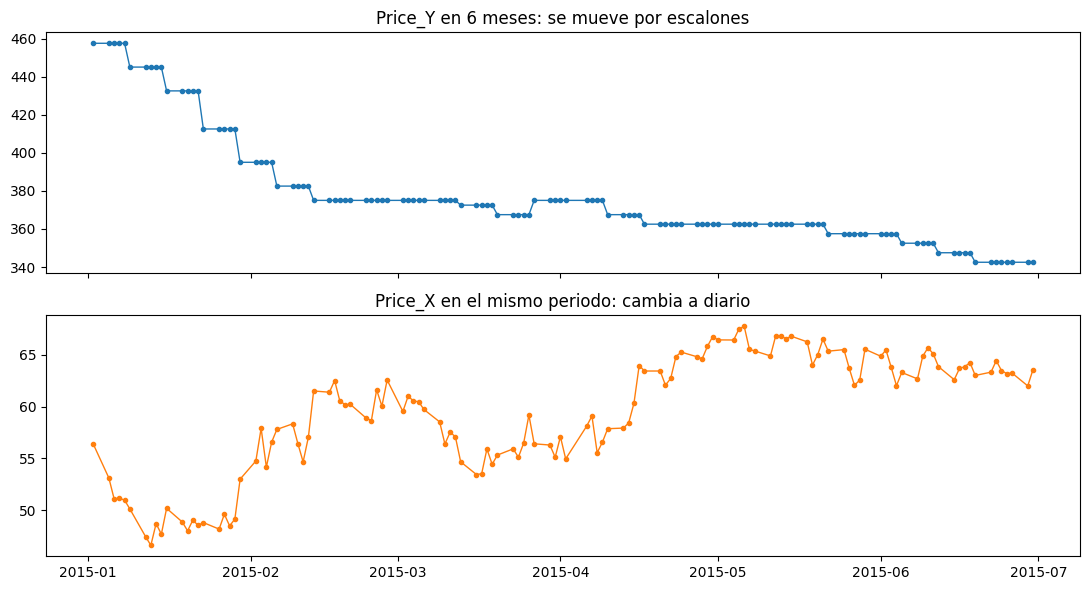

In [8]:
# lo mismo pero visual, para confirmar que el patron es escalonado y no ruido
figura, ejes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
recorte = panel.loc["2015-01":"2015-06"]
ejes[0].plot(recorte.index, recorte["Price_Y"], marker=".", lw=1)
ejes[0].set_title("Price_Y en 6 meses: se mueve por escalones")
ejes[1].plot(recorte.index, recorte["Price_X"], marker=".", lw=1, color="tab:orange")
ejes[1].set_title("Price_X en el mismo periodo: cambia a diario")
figura.tight_layout()

En la grafica de arriba se puede visualizar los patrones de los datos, Y.csv baja por cada cierto tiempo, con tramos planos por varios dias, mientas X.csv cambia todos los días. Son dos frecuencias distinas

Con eso queda claro que Y no aporta informacion nueva todos los días, pero algo importante que cabe de resaltar es que no todos los días tiene un patron, hay fechas que no aparencen en los archivos y considero que se tratan vacias, asi que voy a realizar una verificacion rapida de cuantas celdas vacias se encuentra.

In [9]:
materias = pd.concat([series[0].set_index("Date"), series[1].set_index("Date"), series[2].set_index("Date")], axis=1)
panel_completo = pd.concat([materias, hist.set_index("Date")[EQUIPOS]], axis=1).sort_index()
panel_completo.columns = MATERIAS_PRIMAS + EQUIPOS

ini = panel_completo[["Price_Z", "Price_Equipo1"]].dropna(how="all").index.min()
fin = panel_completo[EQUIPOS].dropna(how="all").index.max()
print(f"ventana de modelado: {ini.date()} a {fin.date()}\n")

calendario = pd.bdate_range(ini, fin)
panel = panel_completo.loc[ini:fin].reindex(calendario)

print(f"dias habiles en el periodo: {len(calendario)}")
print(f"fechas que traian dato: {panel.notna().all(axis=1).sum()}")
print(f"celdas vacias en total: {int(panel.isna().sum().sum())}\n")
print("por columna:")
print(panel.isna().sum())

ventana de modelado: 2010-01-01 a 2023-08-31

dias habiles en el periodo: 3565
fechas que traian dato: 3530
celdas vacias en total: 105

por columna:
Price_X          35
Price_Y           0
Price_Z           0
Price_Equipo1    35
Price_Equipo2    35
dtype: int64


C:\Users\eroza\AppData\Local\Temp\ipykernel_15768\2678211518.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  materias = pd.concat([series[0].set_index("Date"), series[1].set_index("Date"), series[2].set_index("Date")], axis=1)


In [10]:
faltantes = panel[panel.isna().any(axis=1)]
print(f"{len(faltantes)} fechas con algun hueco. las primeras:")
print(faltantes.head(10))

print("\nen que mes del anio caen:")
print(faltantes.index.month.value_counts().sort_index())

35 fechas con algun hueco. las primeras:
            Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
2010-01-01      NaN    527.5  2225.25            NaN            NaN
2010-04-02      NaN    645.0  2327.25            NaN            NaN
2011-04-22      NaN    720.0  2720.50            NaN            NaN
2011-12-26      NaN    610.0  1970.25            NaN            NaN
2012-01-02      NaN    610.0  2005.75            NaN            NaN
2012-04-06      NaN    647.5  2050.25            NaN            NaN
2012-12-25      NaN    552.5  2043.25            NaN            NaN
2013-01-01      NaN    555.0  2093.25            NaN            NaN
2013-03-29      NaN    570.0  1861.50            NaN            NaN
2013-12-25      NaN    522.5  1753.25            NaN            NaN

en que mes del anio caen:
1     10
3      3
4     11
12    11
Name: count, dtype: int64


En total hay 105 días, lo cual puedo intepretar que las celdas vacias pertenecen a fechas feriadas, no estan repartidos por al azar. Son días que simplemente no se cotizo y quedaron vacias

Pero aqui cuenta mucho como se manejan los vacios o nulos, en la estadistica  existe un metodo estadistico que se llama LOCF (last observation carried forward) y es el tratamiento estandar para huecos por dias sin cotizacion en series de precios. La alternativa, interpolar, asume que el precio se movio suavemente entre las dos fechas, lo cual inventa cotizaciones que nunca existieron.

In [11]:
panel = panel.ffill(limit=5)
print(f"celdas vacias despues del ffill: {int(panel.isna().sum().sum())}")
print(panel[panel.isna().any(axis=1)])

celdas vacias despues del ffill: 3
            Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
2010-01-01      NaN    527.5  2225.25            NaN            NaN


### Resumen de la fase 1

**Lo que encontre:**
- Los cuatro archivos vienen en formatos distintos y hay que normalizarlos  uno por uno.
- El historico y los archivos sueltos son identicos donde se solapan.
- X tiene 154 observaciones posteriores al ultimo precio de equipo.
- Y solo se actualiza cada varios dias, aunque el archivo sea diario.

**Lo que decidi:**
- Fuente: los archivos individuales.
- Ventana de modelado: 2010-01-01 a 2023-08-31, limitada por el precio de los equipos.
- Relleno: `ffill` con tope de 5 dias habiles.
- Frecuencia de analisis: mensual, por el estancamiento de Y.

<a id="fase2"></a>
## Fase 2. 

En la fase 1 ya decidi que el analisis va hacer mensual, solo que falta saber si el trabajo con los precios en bruto o transformados, para esto hago un analisis

## EL problema de correlacionar precios en bruto

Dos series que suben con el tiempo se ven correlacionadas aunque no tengan una relacion en si, eso se dectecta a través de una prueba llamada ADF 

In [12]:
diario = pd.read_csv("../Datos/procesado/panel_diario.csv", index_col=0, parse_dates=True).dropna()
mensual = diario.resample("ME").mean()      
logaritmos = np.log(mensual)                 
retornos = logaritmos.diff().dropna()        
print(f"{len(mensual)} meses")

164 meses


In [13]:
from statsmodels.tsa.stattools import adfuller

for col in logaritmos.columns:
    p_niv = adfuller(logaritmos[col], autolag="AIC")[1]
    p_ret = adfuller(retornos[col], autolag="AIC")[1]
    print(f"{col}: en niveles p={p_niv:.4f} ({'ok' if p_niv<0.05 else 'NO estacionaria'}), "
          f"en retornos p={p_ret:.6f}")

Price_X: en niveles p=0.3313 (NO estacionaria), en retornos p=0.000000
Price_Y: en niveles p=0.3569 (NO estacionaria), en retornos p=0.000855
Price_Z: en niveles p=0.2274 (NO estacionaria), en retornos p=0.000000
Price_Equipo1: en niveles p=0.3510 (NO estacionaria), en retornos p=0.000794
Price_Equipo2: en niveles p=0.2349 (NO estacionaria), en retornos p=0.000000


X, Z y Equipo1 no son estacionarias en niveles. En cambio en retornos se puede apreciar que si son estacionarias. ¿Cuando saber si esta estacionaria?. Simple porque el valor de P sea menor a 0.05, si es mayor a 0.05 no es estacionaria por lo tanto.

**Descarto las correlaciones sobre precios en bruto.** Para verlo, las dos versiones lado a lado.

In [14]:
for eq in EQUIPOS:
    for m in MATERIAS_PRIMAS:
        cn = logaritmos[m].corr(logaritmos[eq])
        cr = retornos[m].corr(retornos[eq])
        print(f"{eq} vs {m}: niveles {cn:.3f}, retornos {cr:.3f}")
    print()

Price_Equipo1 vs Price_X: niveles 0.620, retornos 0.337
Price_Equipo1 vs Price_Y: niveles 0.999, retornos 0.996
Price_Equipo1 vs Price_Z: niveles 0.852, retornos 0.441

Price_Equipo2 vs Price_X: niveles 0.622, retornos 0.506
Price_Equipo2 vs Price_Y: niveles 0.924, retornos 0.652
Price_Equipo2 vs Price_Z: niveles 0.986, retornos 0.957



Z contra Equipo1 cae de +0.852 a +0.441. Esos 41 puntos eran tendencia compartida, no relacion. Y contra Equipo1 se mantiene alto en ambas: esa si sobrevive.

In [15]:
for eq in EQUIPOS:
    for m in MATERIAS_PRIMAS:
        corrs = {k: retornos[m].shift(k).corr(retornos[eq]) for k in range(4)}
        print(f"{eq} vs {m}: " + "  ".join(f"k={k}:{c:.3f}" for k,c in corrs.items()))
    print()

Price_Equipo1 vs Price_X: k=0:0.337  k=1:0.277  k=2:0.063  k=3:-0.126
Price_Equipo1 vs Price_Y: k=0:0.996  k=1:0.427  k=2:-0.046  k=3:-0.064
Price_Equipo1 vs Price_Z: k=0:0.441  k=1:0.405  k=2:0.146  k=3:-0.050

Price_Equipo2 vs Price_X: k=0:0.506  k=1:0.252  k=2:0.045  k=3:-0.112
Price_Equipo2 vs Price_Y: k=0:0.652  k=1:0.266  k=2:-0.030  k=3:-0.041
Price_Equipo2 vs Price_Z: k=0:0.957  k=1:0.317  k=2:0.033  k=3:-0.013



**Descarto el modelo con rezagos.** El mejor sin duda es k=0 en los seis pares, las materias se mueven el mismo mes. Para proyectar a futuro habra que proyectar tambien las materias, y eso se puede agregar con incertidumbre 

In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(retornos[MATERIAS_PRIMAS])
for i, c in enumerate(X.columns):
    if c != "const":
        print(f"{c}: VIF {variance_inflation_factor(X.values, i):.2f}")

print()
for eq in EQUIPOS:
    modelo = sm.OLS(retornos[eq], X).fit()
    print(f"{eq}  R2={modelo.rsquared:.4f}")
    for m in MATERIAS_PRIMAS:
        print(f"   {m}: p {modelo.pvalues[m]:.2e} "
              f"{'significativa' if modelo.pvalues[m]<0.05 else 'no'}")

Price_X: VIF 1.27
Price_Y: VIF 1.25
Price_Z: VIF 1.41

Price_Equipo1  R2=0.9930
   Price_X: p 9.50e-07 significativa
   Price_Y: p 1.48e-164 significativa
   Price_Z: p 9.42e-01 no
Price_Equipo2  R2=0.9893
   Price_X: p 7.97e-11 significativa
   Price_Y: p 3.42e-69 significativa
   Price_Z: p 1.78e-132 significativa


VIF entre 1.2 y 1.3, las tres pueden entrar juntas, VIF o  FIV (Factor de Inflación de la Varianza) en español,  una medida estadística que se usa en los modelos de regresión múltiple. Sirve para detectar y medir cuánta multicolinealidad (la correlación o relación lineal entre las variables independientes)

En este caso Equipo1 lo explica Y, Equipo2 lo explican Y y Z, X no aparece.Digo preliminar porque falta revisar los residuos. Un R2 alto no garantiza que la especificacion sea correcta, y eso es lo que se ve la siguiente seccion.

<a id="fase3"></a>
## Fase 3. El diagnostico que cambio el modelo

Aqui esta el giro del analisis. El modelo de la fase 2 se veia bien hasta que mire los residuos.

In [17]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

modelo_dif = sm.OLS(retornos["Price_Equipo1"], sm.add_constant(retornos[MATERIAS_PRIMAS])).fit()
lb = acorr_ljungbox(modelo_dif.resid, lags=[12], return_df=True)["lb_pvalue"].iloc[0]

print(f"R2 = {modelo_dif.rsquared:.4f}")
print(f"Durbin-Watson = {durbin_watson(modelo_dif.resid):.3f}   (2 es sano)")
print(f"rho1 = {modelo_dif.resid.autocorr(1):+.3f}")
print(f"Ljung-Box p = {lb:.4f}   (>0.05 seria ruido blanco)")

R2 = 0.9930
Durbin-Watson = 2.863   (2 es sano)
rho1 = -0.435
Ljung-Box p = 0.0005   (>0.05 seria ruido blanco)


R2 de 0.99 con residuos enfermos. DW de 2.86 indica autocorrelacion **negativa**: los
errores zigzaguean, uno positivo y el siguiente negativo.

El valor de rho1 cerca de -0.5 es una firma conocida: aparece cuando diferencias una serie
que no lo necesitaba. Lo compruebo con datos inventados.

In [18]:
rng = np.random.default_rng(0)
serie_ya_estacionaria = rng.normal(0, 1, 5000)
print(f"rho1 al diferenciar de mas: {pd.Series(np.diff(serie_ya_estacionaria)).autocorr(1):+.3f}")

rho1 al diferenciar de mas: -0.505


-0.499. La firma es real.

Entonces la relacion vive en los precios, no en los cambios. Que eso funcione con series
no estacionarias tiene nombre: **cointegracion**. Series que deambulan pero juntas, de
modo que la distancia entre ellas si es estable. Se prueba regresando en niveles y viendo
si los residuos son estacionarios (Engle-Granger).

In [19]:
for eq in EQUIPOS:
    m_niv = sm.OLS(logaritmos[eq], sm.add_constant(logaritmos[MATERIAS_PRIMAS])).fit()
    p_eg = adfuller(m_niv.resid, autolag="AIC")[1]
    print(f"{eq}: R2 {m_niv.rsquared:.4f}, DW {durbin_watson(m_niv.resid):.2f}, "
          f"ADF residuos p={p_eg:.6f} -> {'COINTEGRADO' if p_eg<0.05 else 'no'}")
    for m in MATERIAS_PRIMAS:
        print(f"   {m}: beta {m_niv.params[m]:+.4f}, p {m_niv.pvalues[m]:.2e}")
    print(f"   suma elasticidades: {m_niv.params[MATERIAS_PRIMAS].sum():.4f}\n")

Price_Equipo1: R2 0.9998, DW 1.60, ADF residuos p=0.000000 -> COINTEGRADO
   Price_X: beta +0.0331, p 1.28e-65
   Price_Y: beta +0.9715, p 6.15e-242
   Price_Z: beta -0.0065, p 6.93e-02
   suma elasticidades: 0.9982

Price_Equipo2: R2 0.9995, DW 1.17, ADF residuos p=0.000009 -> COINTEGRADO
   Price_X: beta +0.0285, p 2.91e-55
   Price_Y: beta +0.2047, p 2.51e-132
   Price_Z: beta +0.7602, p 1.03e-196
   suma elasticidades: 0.9934



Cointegrado en ambos y el DW volvio a la zona sana: el sintoma desaparecio al corregir la especificacion. las elasticidades suman 1.00. Si todos los insumos suben 10%, el equipo sube 10%. Eso no es un ajuste estadistico, es la formula de costeo del proveedor.

**Descarto el modelo en diferencias.** No por su R2, sino porque sus residuos indicaban mala especificacion y la alternativa paso el test formal.

**Descarto cierre de mes como agregacion.** Probe las dos: promedio da R2 0.9998 contra 0.9930 del cierre. El precio de compra refleja el costo de todo el mes de produccion.

In [20]:
for eq, variables in [("Price_Equipo1", ["Price_X","Price_Y"]), ("Price_Equipo2", MATERIAS_PRIMAS)]:
    err_modelo, err_naive = [], []
    for t in range(60, len(logaritmos)):
        mod = sm.OLS(logaritmos[eq].iloc[:t],
                     sm.add_constant(logaritmos[variables].iloc[:t])).fit()
        pred = float(mod.params.values @ np.r_[1.0, logaritmos[variables].iloc[t].values])
        real = logaritmos[eq].iloc[t]
        err_modelo.append(abs(np.expm1(pred - real)))
        err_naive.append(abs(np.expm1(logaritmos[eq].iloc[t-1] - real)))
    em, en = np.mean(err_modelo)*100, np.mean(err_naive)*100
    print(f"{eq}: MAPE modelo {em:.3f}%, naive {en:.3f}%, mejora {100*(1-em/en):.1f}%")

Price_Equipo1: MAPE modelo 0.331%, naive 4.995%, mejora 93.4%
Price_Equipo2: MAPE modelo 0.355%, naive 3.553%, mejora 90.0%


Aguanta fuera de muestra.

**Descarto: ventana rodante de 60 meses.** Da 0.336% contra 0.331% de la expansiva.
Empate, o sea que los coeficientes son estables. Gana la expansiva porque usa todo.

**Descarto : Z en el modelo del Equipo 1.** p=0.069 y coeficiente negativo. Un insumo con
elasticidad negativa no tiene sentido economico, y quitarla no cambia el MAPE.


<a id="fase4"></a>
## Fase 4. Cuanto del futuro se puede saber

Como las materias no anticipan, para proyectar los equipos hay que proyectar tambien las
materias. La pregunta clave es de donde viene el error.

In [21]:
for m in MATERIAS_PRIMAS:
    r = logaritmos[m].diff().dropna()
    print(f"{m}: AR(1) {r.autocorr(1):+.3f}, deriva anual {r.mean()*12*100:+.2f}%, "
          f"volatilidad anual {r.std()*np.sqrt(12)*100:.1f}%")

Price_X: AR(1) +0.343, deriva anual +0.74%, volatilidad anual 30.9%
Price_Y: AR(1) +0.418, deriva anual +0.12%, volatilidad anual 21.2%
Price_Z: AR(1) +0.241, deriva anual -0.34%, volatilidad anual 15.8%


**Descarto: random walk puro para simular las materias.** Los retornos traen autocorrelacion de 0.24 a 0.42, hay inercia que un RW tira a la basura. Uso AR(1).

**Descarto : ARIMA(1,1,1).** Lo compare contra el AR(1): 4.49% vs 4.80% a un mes, 26.6% vs 27.2% a doce. Tres decimas no pagan la complejidad con 164 observaciones.

### De donde viene el error

Corri el backtest dos veces: con las materias reales del mes objetivo (condicional) y pronosticandolas (total).

El error del modelo es plano. Todo el crecimiento viene de no saber donde van a estar los
commodities: a 12 meses, el 98.5% del error total son las exogenas.

**Descarto: horizonte de 12 meses.** Una banda de 16% deja reservar contingencia con
criterio; una de 26% no cambia ninguna decision.

###  Conclusion por el momento

Contra el naive del propio equipo, en pronostico incondicional, el modelo **empata**
(4.52% vs 4.76% a un mes).

Frente al naive de grupo, pronostico incondicional de grupo, el modelo empata 4,52% vs 4,76% a un mes. Tiene su explicación, puesto que, en este caso, si el equipo es determinista de las materias que son cuasi random walk, entonces el equipo también lo es. Ningún modelo puede batir a uno random walk sobre un random walk. Por otra parte, también sirve para:

Entonces sirve para:
1. **Condicional.** Con 0.35% de error, cualquier vision sobre los commodities se traduce
   en precio de equipo. El naive no puede incorporar informacion externa.
2. **Descomposicion.** Saber que el Equipo1 es 97% Y permite negociar y cubrir donde importa.
3. **Escenarios.** "Si Z sube 20%, el Equipo2 sube 14.87%". El naive no responde eso.
